# Results Analysis and Explainability

In [ ]:
from pathlib import Path
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.metrics import classification_report

from src.data_utils import load_logmel_features, make_class_mappings
from src.cnn import AudioCNN, GradCAM, prepare_logmel_tensor
from src.visualization import (
    save_figure,
    plot_metric_comparison_with_error_bars,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_average_training_history,
    plot_gradcam_example,
)

ROOT = Path.cwd().parent.resolve()

DATA_DIR = ROOT / "data"
FEATURE_DIR = DATA_DIR / "features"
RESULTS_DIR = ROOT / "results/models"
FIGURES_DIR = ROOT / "figures"

print("PROJECT_ROOT", ROOT)
print("RESULTS_DIR", RESULTS_DIR)
print("FIGURES_DIR", FIGURES_DIR)

PROJECT_ROOT D:\Projects\Audio\Audio Pattern Recognition
RESULTS_DIR D:\Projects\Audio\Audio Pattern Recognition\results\models
FIGURES_DIR D:\Projects\Audio\Audio Pattern Recognition\figures


## Helper Functions

In [2]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def load_predictions(path):
    return pd.read_csv(path)


def load_summary(model_dir):
    return load_json(model_dir / "summary_metrics.json")


def load_histories(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def make_summary_row(model_name, summary):
    return {
        "model": model_name,
        "accuracy_mean": summary["accuracy_mean"],
        "accuracy_std": summary["accuracy_std"],
        "f1_macro_mean": summary["f1_macro_mean"],
        "f1_macro_std": summary["f1_macro_std"],
        "f1_weighted_mean": summary["f1_weighted_mean"],
        "f1_weighted_std": summary["f1_weighted_std"],
    }

## Loading saved experiment outputs

In [3]:
SVM_DIR = RESULTS_DIR / "svm"
RF_DIR = RESULTS_DIR / "random_forest"
CNN_DIR = RESULTS_DIR / "cnn"

svm_summary = load_summary(SVM_DIR)
rf_summary = load_summary(RF_DIR)
cnn_summary = load_summary(CNN_DIR)

svm_predictions = load_predictions(SVM_DIR / "predictions.csv")
rf_predictions = load_predictions(RF_DIR / "predictions.csv")
cnn_predictions = load_predictions(CNN_DIR / "predictions.csv")

cnn_histories = load_histories(CNN_DIR / "histories.pk1")

print("SVM predictions:", svm_predictions.shape)
print("RF predictions:", rf_predictions.shape)
print("CNN predictions:", cnn_predictions.shape)

SVM predictions: (8732, 6)
RF predictions: (8732, 6)
CNN predictions: (8732, 6)


## Overall model comparison

In [4]:
comparison_df = pd.DataFrame(
    [
        make_summary_row("SVM", svm_summary),
        make_summary_row("Random Forest", rf_summary),
        make_summary_row("Tuned CNN", cnn_summary),
    ]
)

display(comparison_df)

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,SVM,0.683187,0.060959,0.698132,0.057547,0.676801,0.063395
1,Random Forest,0.665438,0.039295,0.680262,0.033327,0.660076,0.040964
2,Tuned CNN,0.719894,0.040023,0.732608,0.043107,0.713242,0.042517


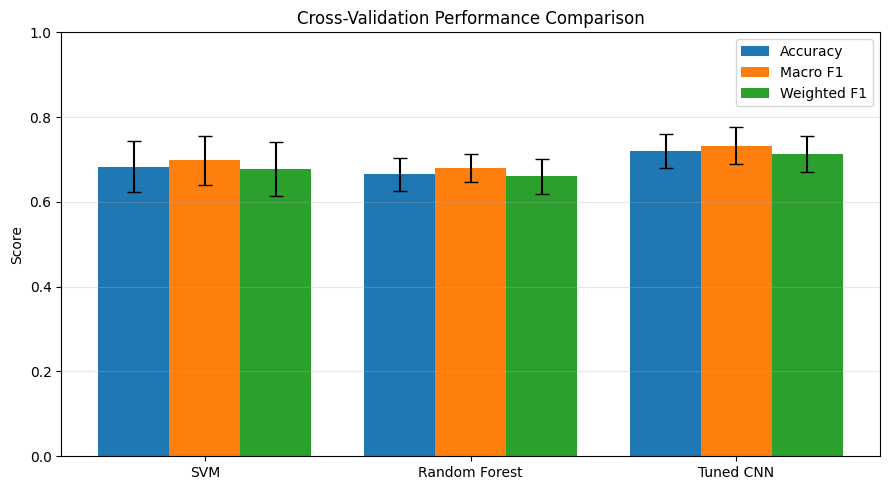

In [ ]:
fig, ax = plot_metric_comparison_with_error_bars(
    comparison_df,
    title="Cross-Validation Performance Comparison",
)

save_figure(fig, "model_metric_comparison.png", FIGURES_DIR)
plt.show()

## Fold-level comparison

In [6]:
svm_folds = pd.read_csv(SVM_DIR / "fold_metrics.csv")
rf_folds = pd.read_csv(RF_DIR / "fold_metrics.csv")
cnn_folds = pd.read_csv(CNN_DIR / "fold_metrics.csv")

svm_folds["model"] = "SVM"
rf_folds["model"] = "Random Forest"
cnn_folds["model"] = "Tuned CNN"

folds_all = pd.concat([svm_folds, rf_folds, cnn_folds], ignore_index=True)

display(folds_all[["model", "test_fold", "accuracy", "f1_macro", "f1_weighted"]])

,model,test_fold,accuracy,f1_macro,f1_weighted
0,SVM,1,0.636884,0.665305,0.616677
1,SVM,2,0.665541,0.681713,0.657911
2,SVM,3,0.568649,0.586322,0.558008
3,SVM,4,0.682828,0.670308,0.678954
4,SVM,5,0.778846,0.782315,0.772363
5,SVM,6,0.650061,0.673985,0.652294
6,SVM,7,0.739857,0.752643,0.737986
7,SVM,8,0.658809,0.683447,0.655438
8,SVM,9,0.713235,0.729159,0.702515
9,SVM,10,0.737157,0.756122,0.735864


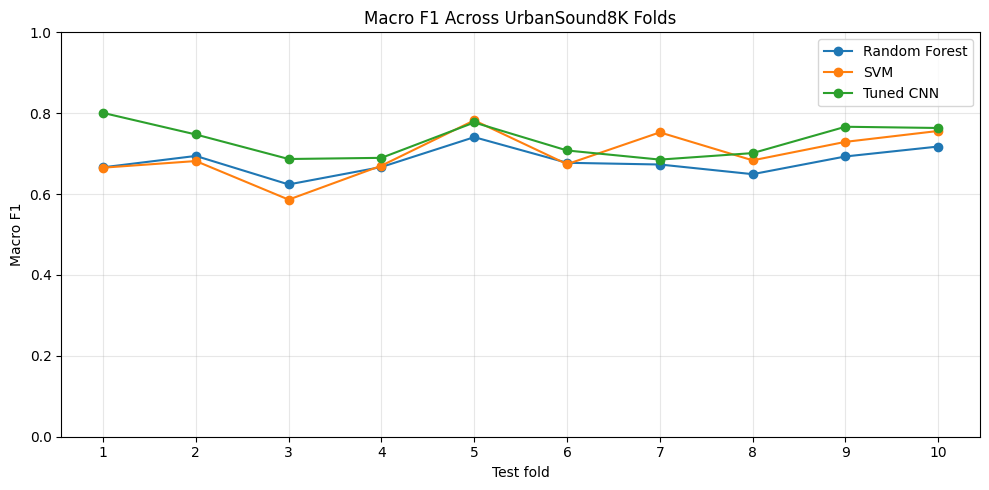

In [7]:
from matplotlib.pyplot import savefig

fig, ax = plt.subplots(figsize=(10, 5))

for model_name, group in folds_all.groupby("model"):
    ax.plot(group["test_fold"], group["f1_macro"], marker="o", label=model_name)

ax.set_title("Macro F1 Across UrbanSound8K Folds")
ax.set_xlabel("Test fold")
ax.set_ylabel("Macro F1")
ax.set_xticks(sorted(folds_all["test_fold"].unique()))
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
save_figure(fig, "fold_macro_f1_comparison.png", FIGURES_DIR)
plt.show()

## Confusion matrix analysis

In [8]:
class_table = (
    cnn_predictions[["true_class_id", "true_class"]]
    .drop_duplicates()
    .rename(columns={"true_class_id": "class_id", "true_class": "class"})
    .sort_values("class_id")
    .reset_index(drop=True)
)

class_ids = class_table["class_id"].to_numpy()
class_names = class_table["class"].to_numpy()

display(class_table)

,class_id,class
0,0,air_conditioner
1,1,car_horn
2,2,children_playing
3,3,dog_bark
4,4,drilling
5,5,engine_idling
6,6,gun_shot
7,7,jackhammer
8,8,siren
9,9,street_music


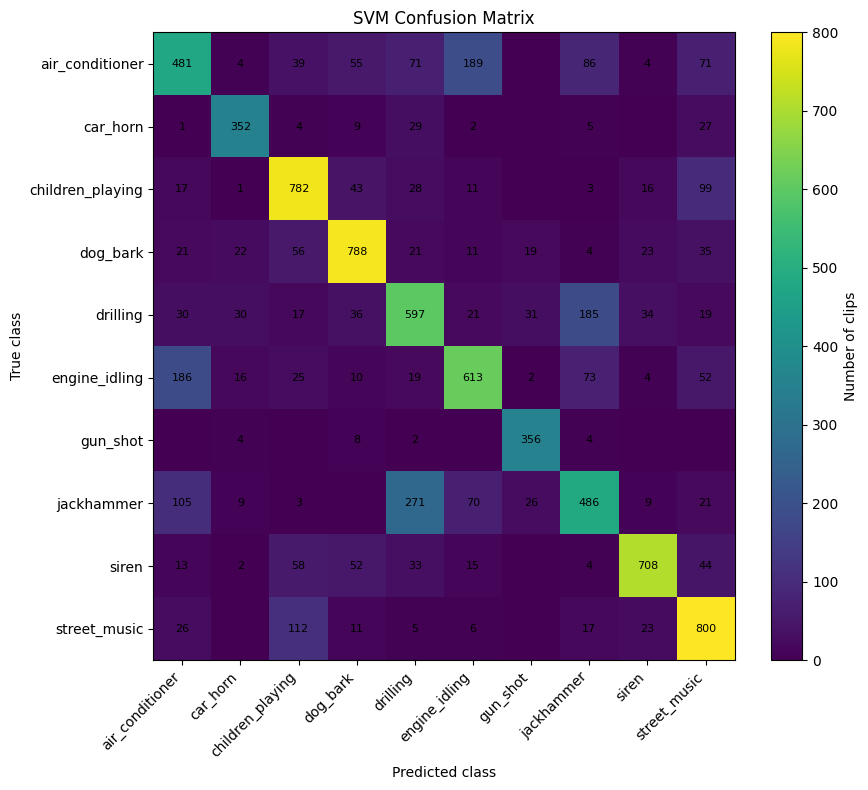

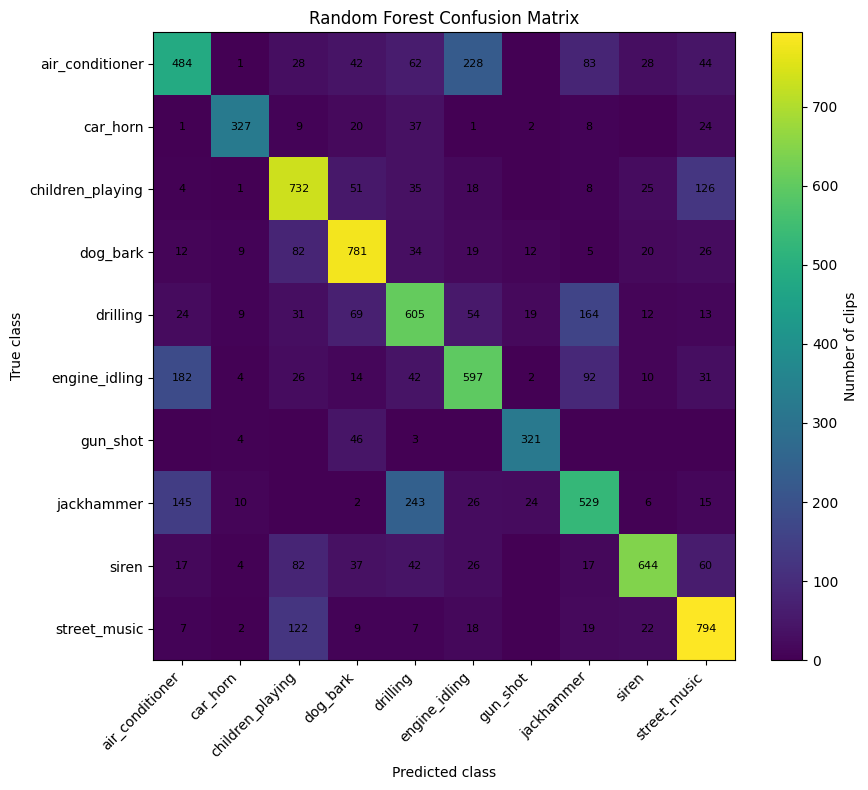

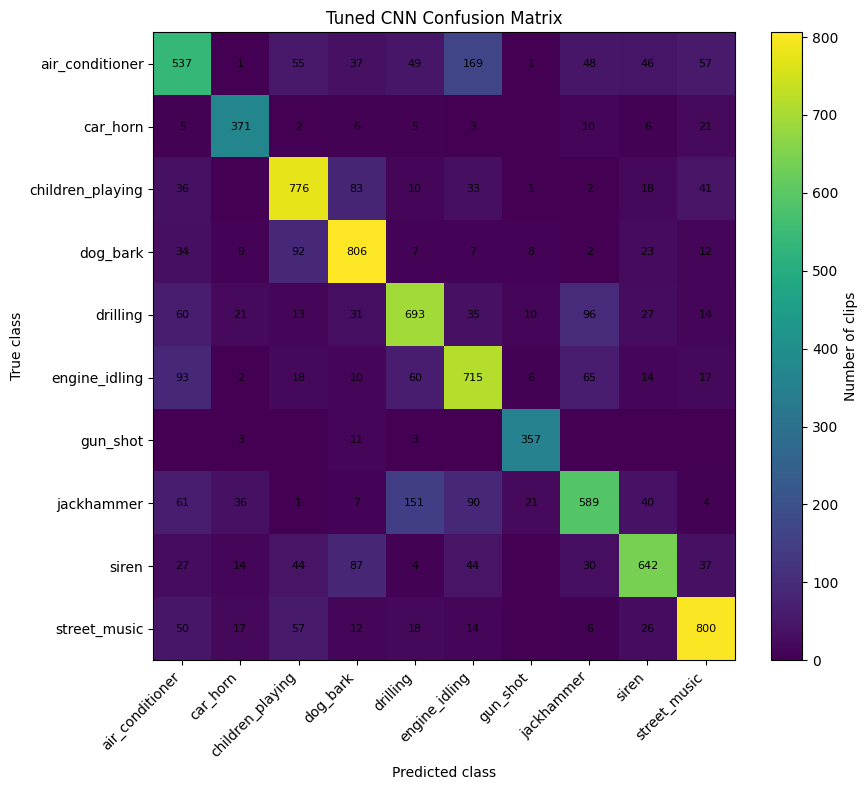

In [9]:
prediction_sets = {
    "SVM": svm_predictions,
    "Random Forest": rf_predictions,
    "Tuned CNN": cnn_predictions,
}

for model_name, pred_df in prediction_sets.items():
    fig, ax, cm = plot_confusion_matrix(
        y_true=pred_df["true_class_id"],
        y_pred=pred_df["pred_class_id"],
        class_ids=class_ids,
        class_names=class_names,
        title=f"{model_name} Confusion Matrix",
        normalize=False,
    )

    filename = f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png"
    save_figure(fig, filename, FIGURES_DIR)
    plt.show()

## Class-level performance

In [10]:
def classification_report_dataframe(pred_df, model_name):
    report = classification_report(
        pred_df["true_class_id"],
        pred_df["pred_class_id"],
        labels=class_ids,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    df = pd.DataFrame(report).T
    df = df.loc[class_names, ["precision", "recall", "f1-score", "support"]]
    df = df.reset_index().rename(columns={"index": "class"})
    df["model"] = model_name

    return df


class_reports = pd.concat(
    [
        classification_report_dataframe(svm_predictions, "SVM"),
        classification_report_dataframe(rf_predictions, "Random Forest"),
        classification_report_dataframe(cnn_predictions, "Tuned CNN"),
    ],
    ignore_index=True,
)

f1_by_class = class_reports.pivot(index="class", columns="model", values="f1-score")
display(f1_by_class)

model,Random Forest,SVM,Tuned CNN
class,,,
air_conditioner,0.515991,0.511702,0.564372
car_horn,0.817500,0.810127,0.821705
children_playing,0.693182,0.746183,0.754130
dog_bark,0.754225,0.783300,0.771292
drilling,0.573460,0.575145,0.693000
engine_idling,0.600906,0.632611,0.677725
gun_shot,0.851459,0.881188,0.917738
jackhammer,0.549610,0.520621,0.637446
siren,0.759434,0.809143,0.725014


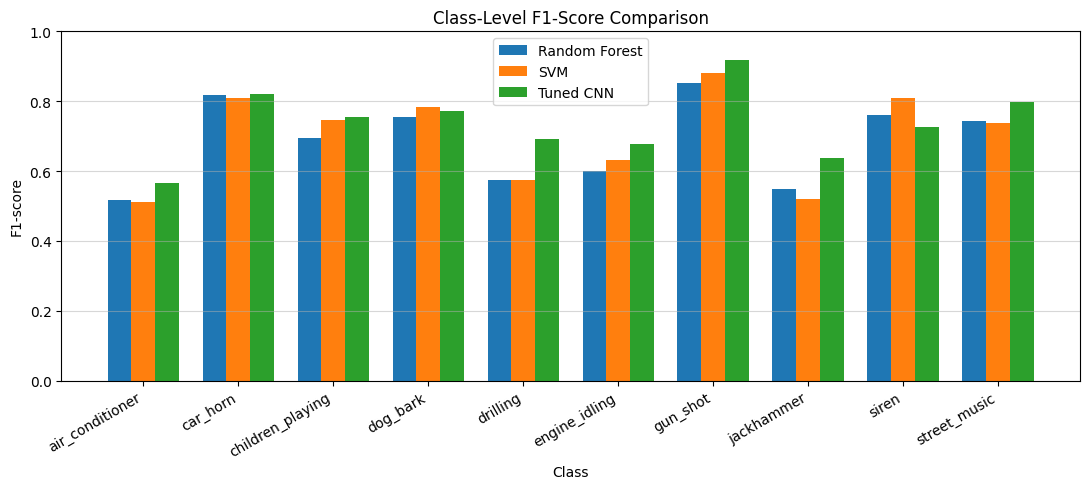

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(f1_by_class.index))
width = 0.25

ax.bar(x - width, f1_by_class["Random Forest"], width, label="Random Forest")
ax.bar(x, f1_by_class["SVM"], width, label="SVM")
ax.bar(x + width, f1_by_class["Tuned CNN"], width, label="Tuned CNN")

ax.set_title("Class-Level F1-Score Comparison")
ax.set_xlabel("Class")
ax.set_ylabel("F1-score")
ax.set_xticks(x)
ax.set_xticklabels(f1_by_class.index, rotation=30, ha="right")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.5)
ax.legend()

plt.tight_layout()
save_figure(fig, "class_level_f1_comparison.png", FIGURES_DIR)
plt.show()

## Random Forest explainability: feature importance

In [12]:
rf_importance_path = RF_DIR / "rf_feature_importance.csv"

rf_importance = pd.read_csv(rf_importance_path)
display(rf_importance.head(20))

,feature,importance
0,mfcc_1_max,0.023060
1,mfcc_4_min,0.020939
2,mfcc_1_std,0.014867
3,mfcc_4_mean,0.014159
4,spectral_bandwidth_1_std,0.014001
5,spectral_rolloff_1_min,0.012757
6,mfcc_40_std,0.012366
7,spectral_centroid_1_min,0.012169
8,mfcc_1_mean,0.012050
9,mfcc_4_max,0.011986


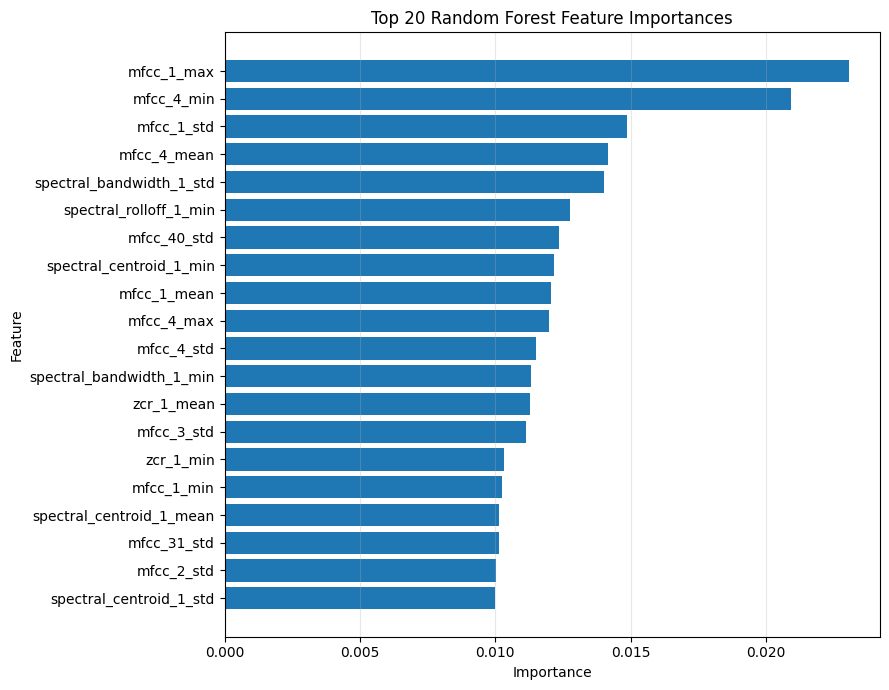

In [13]:
fig, ax = plot_feature_importance(
    rf_importance,
    feature_col="feature",
    importance_col="importance",
    top_n=20,
    title="Top 20 Random Forest Feature Importances",
)

save_figure(fig, "rf_top20_feature_importance.png", FIGURES_DIR)
plt.show()

## CNN Training Curves

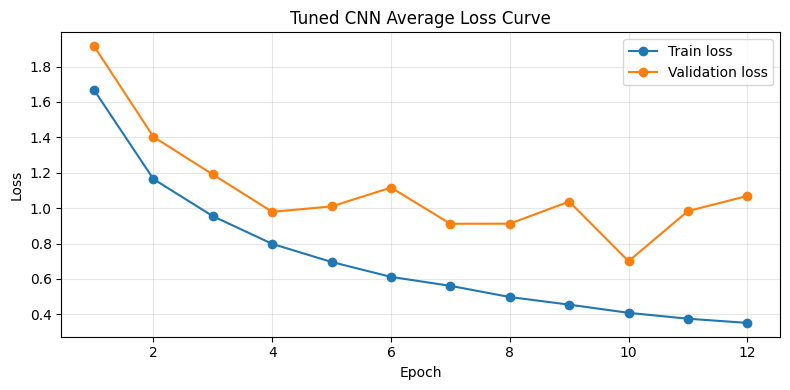

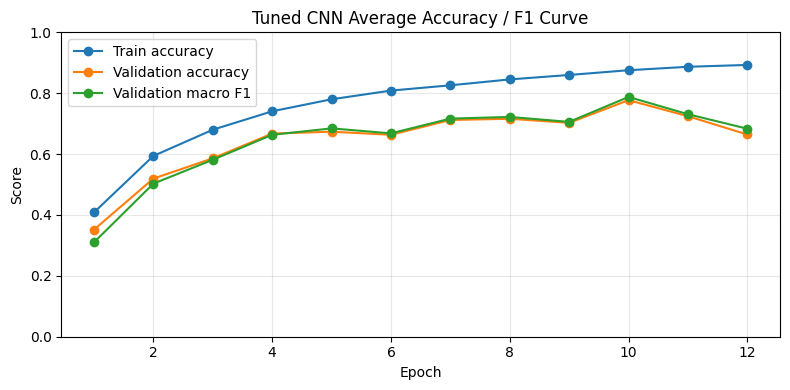

In [14]:
(fig_loss, ax_loss), (fig_acc, ax_acc) = plot_average_training_history(
    cnn_histories,
    title_prefix="Tuned CNN",
)

save_figure(fig_loss, "cnn_average_loss_curves.png", FIGURES_DIR)
save_figure(fig_acc, "cnn_average_accuracy_curves.png", FIGURES_DIR)

plt.show()

## CNN explainability with Grad-CAM

In [15]:
logmel_path = FEATURE_DIR / "logmel_spectogram.npz"
logmel_data = load_logmel_features(logmel_path)

X_logmel = logmel_data["X"].astype(np.float32)
y_logmel = logmel_data["y"].astype(np.int64)
labels_logmel = logmel_data["labels"]
filenames_logmel = logmel_data["filenames"]

_, _, _, id_to_class = make_class_mappings(y_logmel, labels_logmel)

print("Log-Mel features:", X_logmel.shape)

Log-Mel features: (8732, 128, 173)


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = CNN_DIR / "best_model.pt"
checkpoint = torch.load(model_path, map_location=device)

dropout = checkpoint.get("training_config", {}).get("dropout", 0.5)

model = AudioCNN(num_classes=len(class_ids), dropout=dropout).to(device)
model.load_state_dict(checkpoint)
model.eval()

print("Loaded:", model_path)
print("Device:", device)

C:\Users\rashi\AppData\Local\Temp\ipykernel_3616\2531357907.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Loaded: D:\Projects\Audio\Audio Pattern Recognition\results\models\cnn\best_model.pt
Device: cuda


In [17]:
def generate_gradcam(index):
    logmel = X_logmel[index]
    true_id = int(y_logmel[index])

    mean = X_logmel.mean()
    std = X_logmel.std()

    x = prepare_logmel_tensor(logmel, mean, std, device)

    target_layer = model.features[-4]

    gradcam = GradCAM(model, target_layer)
    cam, pred_id, logits = gradcam(x)
    gradcam.close()

    return (logmel, cam, id_to_class[true_id], id_to_class[pred_id])

## Correctly classified sample

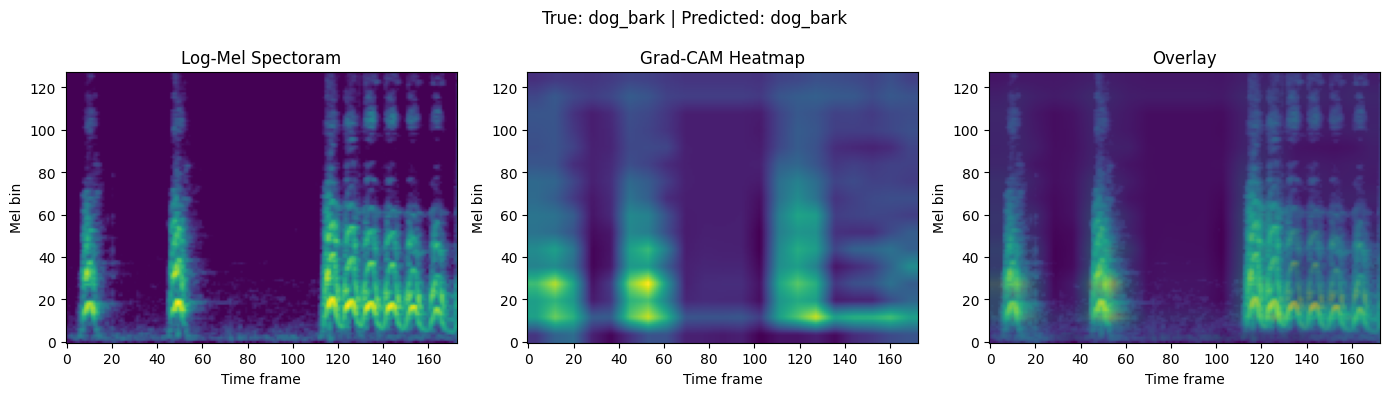

In [18]:
correct = cnn_predictions[
    cnn_predictions["true_class_id"] == cnn_predictions["pred_class_id"]
].iloc[0]

idx = np.where(filenames_logmel == correct["filename"])[0][0]

logmel, cam, true_label, pred_label = generate_gradcam(idx)

fig, axes = plot_gradcam_example(logmel, cam, true_label, pred_label)
save_figure(fig, "cnn_gradcam_correct_example.png", FIGURES_DIR)
plt.show()

## Misclassified sample

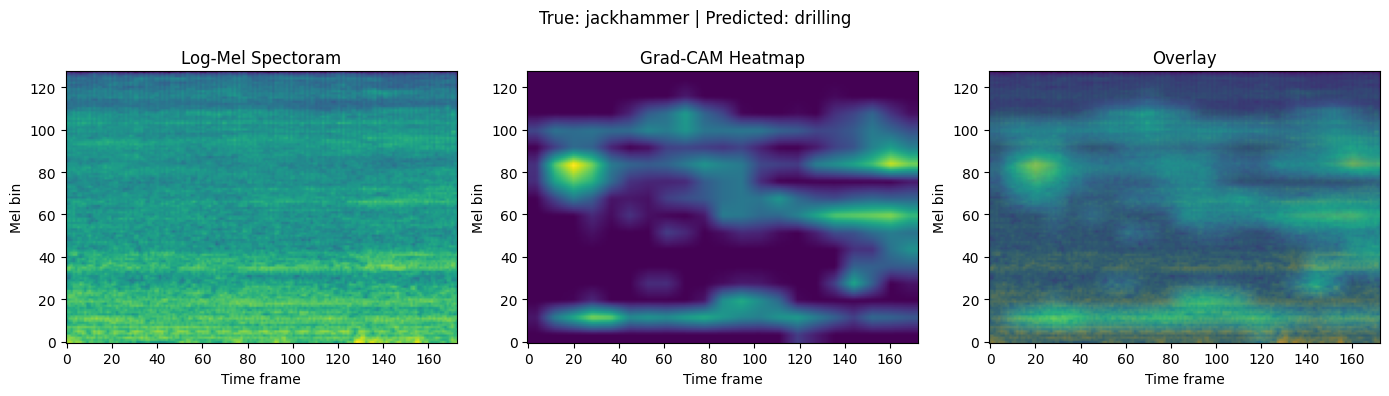

In [19]:
wrong = cnn_predictions[
    cnn_predictions["true_class_id"] != cnn_predictions["pred_class_id"]
].iloc[0]

idx = np.where(filenames_logmel == wrong["filename"])[0][0]

logmel, cam, true_label, pred_label = generate_gradcam(idx)

fig, axes = plot_gradcam_example(logmel, cam, true_label, pred_label)
save_figure(fig, "cnn_gradcam_misclassified_example.png", FIGURES_DIR)
plt.show()

## Misclassified Grad-CAM example

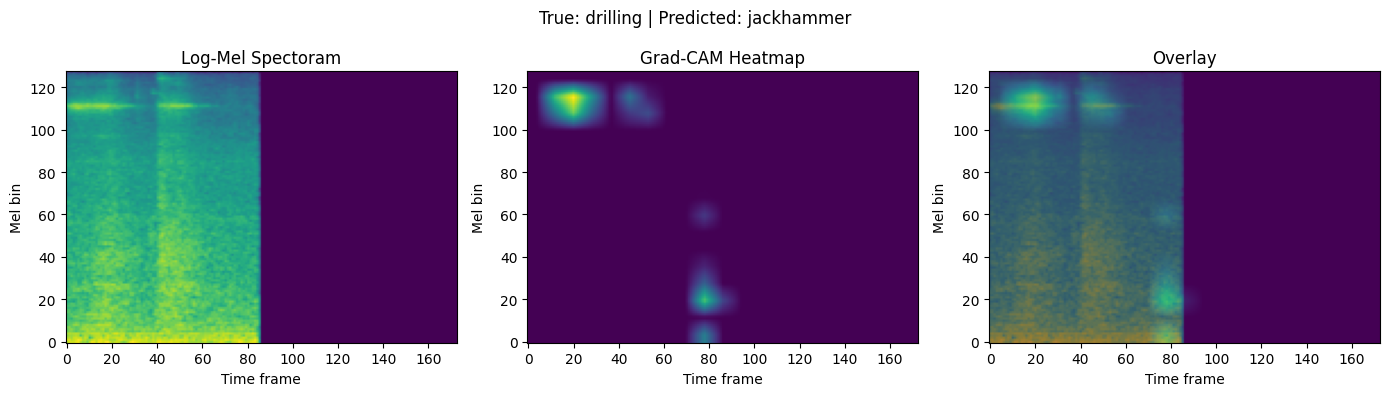

In [ ]:
candidate_errors = cnn_predictions[
    (cnn_predictions["true_class"] == "drilling")
    & (cnn_predictions["pred_class"] == "jackhammer")
]

if len(candidate_errors) == 0:
    candidate_errors = cnn_predictions[
        cnn_predictions["true_class_id"] != cnn_predictions["pred_class_id"]
    ]

wrong = candidate_errors.iloc[0]

idx = np.where(filenames_logmel == wrong["filename"])[0][0]

logmel, cam, true_label, pred_label = generate_gradcam(idx)

fig, axes = plot_gradcam_example(
    logmel=logmel, cam=cam, true_label=true_label, pred_label=pred_label
)

save_figure(fig, "cnn_gradcam_misclassified_example.png", FIGURES_DIR)
plt.show()

## Final summary table

In [ ]:
summary_table = comparison_df.copy()

summary_table["Accuracy"] = (
    summary_table["accuracy_mean"].map(lambda x: f"{x:.3f}")
    + " ± "
    + summary_table["accuracy_std"].map(lambda x: f"{x:.3f}")
)

summary_table["Macro F1"] = (
    summary_table["f1_macro_mean"].map(lambda x: f"{x:.3f}")
    + " ± "
    + summary_table["f1_macro_std"].map(lambda x: f"{x:.3f}")
)

summary_table["Weighted F1"] = (
    summary_table["f1_weighted_mean"].map(lambda x: f"{x:.3f}")
    + " ± "
    + summary_table["f1_weighted_std"].map(lambda x: f"{x:.3f}")
)

summary_table = summary_table[["model", "Accuracy", "Macro F1", "Weighted F1"]].rename(
    columns={"model": "Model"}
)

display(summary_table)

,Model,Accuracy,Macro F1,Weighted F1
0,SVM,0.683 ± 0.061,0.698 ± 0.058,0.677 ± 0.063
1,Random Forest,0.665 ± 0.039,0.680 ± 0.033,0.660 ± 0.041
2,Tuned CNN,0.720 ± 0.040,0.733 ± 0.043,0.713 ± 0.043
